In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Bibliotēkas ielādētas veiksmīgi ✓")

Bibliotēkas ielādētas veiksmīgi ✓


In [2]:
df = pd.read_csv('../week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print(df.head(3))


Datu kopa: 12330 rindas, 30 kolonnas
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   
2       -0.696993                -0.457191      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.691003                -0.624348   
1               -0.244931       -0.668518                -0.590903   
2               -0.244931       -0.691003                -0.624348   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Mar  Month_May  \
0     3.667189   3.229316   -0.317178   -0.308821  ...  -0.427739  -0.612532   
1    -0.457683   1.171473   -0.317178   -0.308821  ...  -0.427739  -0.612532   
2     3.667189   3.229316   -0.317178   -0.308821  ...  -0.427739  -0.612532   

   Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0  -0.566798  -0.215871  -0.194175          -0.083316   
1 

## 1.2. Target mainīgais: PageValues

**PageValues** atspoguļo, cik tuvu klients bija pirkuma veikšanai konkrētajā sesijā.
Augstāka vērtība nozīmē augstāku pirkuma varbūtību un vērtību.

Šis ir **regresijas** uzdevums, jo mēs prognozējam nepārtrauktu skaitlisku vērtību
(nevis kategoriju kā klasifikācijā).
"""

PageValues statistika:
count    1.233000e+04
mean     9.220344e-18
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


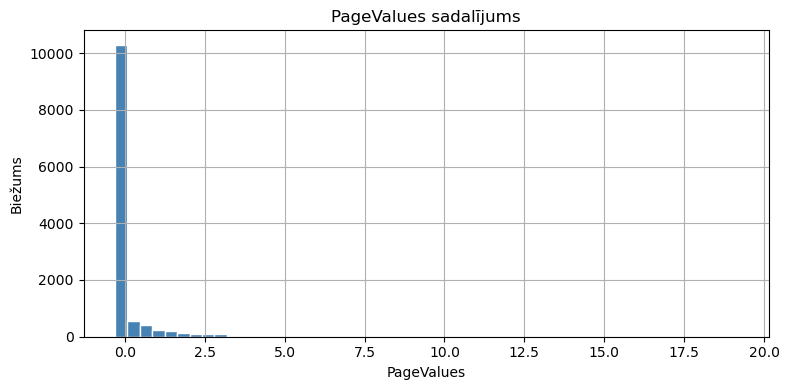

In [3]:
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()


In [4]:
y = df['PageValues']
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")
print(f"Features: {list(X.columns)}")

Features skaits: 28
Target: PageValues
Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'TotalDuration', 'TotalPages', 'ProductFocusRatio']


"""
## Kāpēc izņemam kolonnu Revenue no features?

**Data leakage** notiek, kad modelī iekļaujam informāciju, kas reālā prognozēšanas
brīdī vēl nav pieejama — vai kas satur tiešu "atbildi".

`Revenue` kolonna norāda, vai klients *veica pirkumu*. Šī informācija ir cieši
saistīta ar `PageValues` — augsta PageValues vērtība gandrīz vienmēr nozīmē,
ka klients pirka. Ja mēs iekļautu `Revenue` kā feature, modelis praktiski "redzētu
atbildi" un dotu mākslīgi labus rezultātus, kas reālajā pasaulē nedarbosies.

**Reālajā sistēmā:** kad klients pārlūko lapu, mēs nezinām, vai viņš nopirks.
Tātad Revenue nav pieejams prognozēšanas brīdī — to nedrīkst izmantot kā feature.
"""

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa:   {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa:   2466 rindas


In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


=== Lineāra regresija: rezultāti ===
MSE:  0.9890
RMSE: 0.9945
MAE:  0.5007
R²:   0.0457


## 2.2. Metriku interpretācija

**MAE (Mean Absolute Error)** — vidējā absolūtā kļūda.
Tas nozīmē, ka vidēji modelis kļūdās par ~X PageValues vienībām uz katru klientu.
MAE ir viegli saprotams, jo tas izteikts tajās pašās vienībās kā target.

**RMSE (Root Mean Squared Error)** — kvadrātsakne no vidējās kvadrātiskās kļūdas.
Lielākas kļūdas tiek sodītas vairāk, jo kļūda tiek kāpināta kvadrātā pirms
vidējo aprēķina. Tas nozīmē, ka RMSE ir jutīgāks pret outliers nekā MAE.
Ja RMSE ir ievērojami lielāks par MAE, tas liecina par retām, bet lielām kļūdām.

**R² (R-squared)** — determinācijas koeficients.
Vērtība no 0.0 līdz 1.0, kas parāda, cik daudz no datu variācijas modelis izskaidro.
R² = 0.75 nozīmētu, ka modelis izskaidro 75% no PageValues variācijas.
Ja R² ir zems (piemēram, < 0.3), modelis ir vājš — lielāko daļu variācijas tas
nespēj izskaidrot ar pieejamajām features.

**Vai modelis ir labs?**
PageValues sadalījums ir ļoti asimetrisks — lielākajai daļai klientu vērtība ir 0,
bet retiem klientiem tā ir ļoti augsta. Tas padara regresiju sarežģītu, un pat
"viduvējas" R² vērtības šeit ir sagaidāmas. Svarīgāk ir skatīties uz atlikumu
grafikiem, lai saprastu, kur modelis kļūdās.
"""

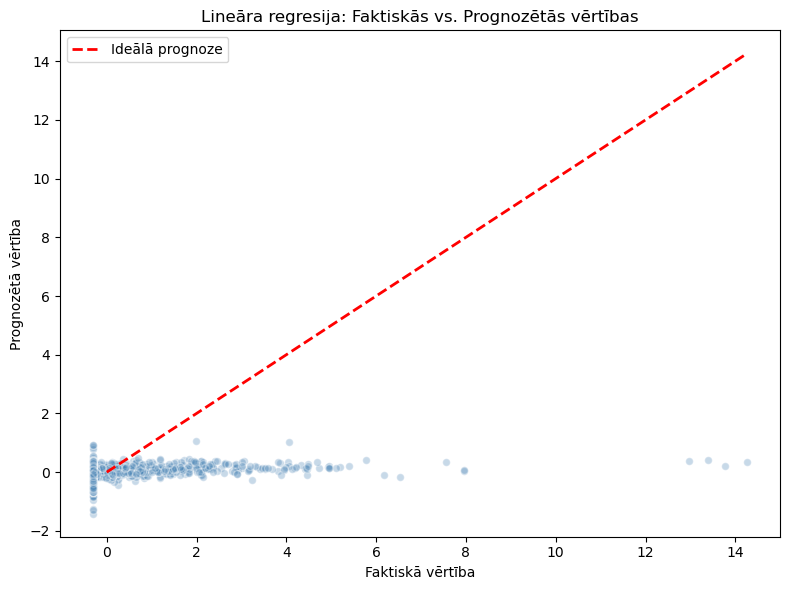

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue',
            edgecolors='white', s=30)

max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

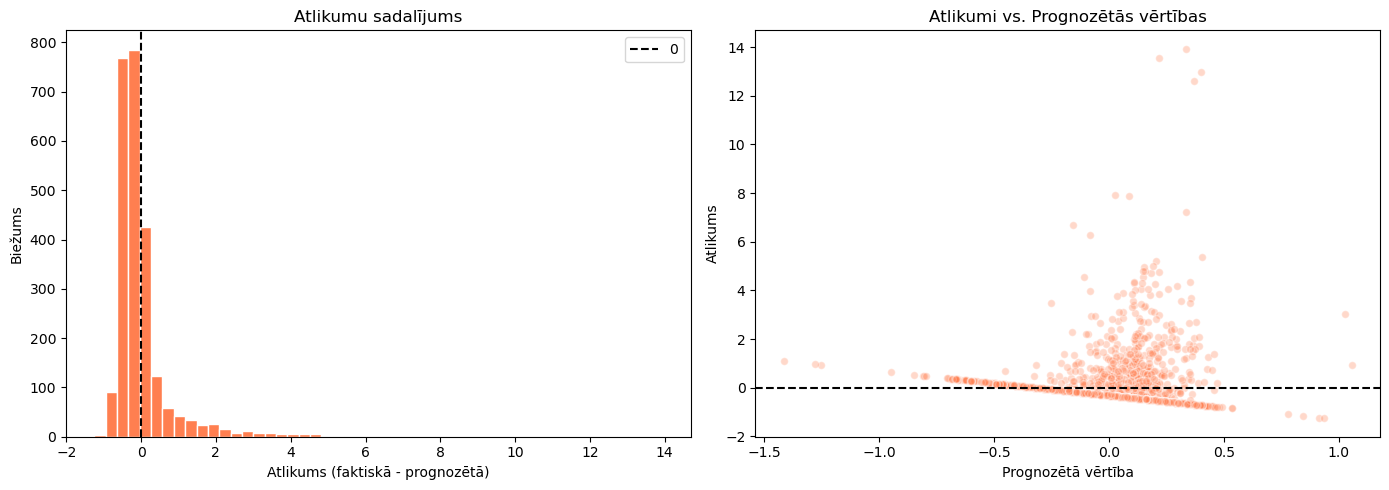

In [9]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--', label='0')
axes[0].legend()

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral',
                edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

"""
## 3.3. Vizualizāciju interpretācija

**Scatter grafiks (faktiskās vs. prognozētās):**
Ideālā gadījumā visi punkti atrastos uz sarkanās pārtrauktās līnijas (y = x).
Ja punkti ir izkaisīti tālu no līnijas — modelis prognozē neprecīzi.
Bieži vērojams, ka zemās vērtības (PageValues = 0) tiek prognozētas salīdzinoši
labi, bet augstās vērtības — ar lielāku kļūdu, jo tādi gadījumi treniņa datos
ir reti.

**Atlikumu histogramma:**
Labs modelis: atlikumi sadalīti simetriski ap 0 (normāls sadalījums).
Ja histogramma ir nobīdīta — modelim ir sistemātiska kļūda (bias).
PageValues gadījumā gaidāms, ka atlikumi nebūs ideāli normāli sadalīti,
jo pats target ir asimetrisks (daudz nulles vērtību).

**Atlikumi vs. prognozētās vērtības:**
Labam modelim punkti jābūt haotiski izkaisītiem ap 0 horizontālo līniju.
Ja ir redzams raksts (piemēram, kļūdas pieaug līdz ar prognozēto vērtību),
tas liecina, ka modelis neuzver nelineāras sakarības.
"""

In [10]:
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

mae_poly  = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly   = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4969
RMSE: 1.0115
R²:   0.0127


In [11]:
comparison = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Polinomiālā regresija (deg=2)'],
    'MAE':     [round(mae, 4),       round(mae_poly, 4)],
    'RMSE':    [round(rmse, 4),      round(rmse_poly, 4)],
    'R²':      [round(r2, 4),        round(r2_poly, 4)]
})

print("=== Modeļu salīdzinājums ===")
print(comparison.to_string(index=False))


=== Modeļu salīdzinājums ===
                      Modelis    MAE   RMSE     R²
            Lineārā regresija 0.5007 0.9945 0.0457
Polinomiālā regresija (deg=2) 0.4969 1.0115 0.0127


In [12]:
lr_train_r2   = lr_model.score(X_train, y_train)
lr_test_r2    = r2_score(y_test, y_pred)

poly_train_r2 = poly_pipeline.score(X_train, y_train)
poly_test_r2  = r2_score(y_test, y_pred_poly)

print("=== Overfitting pārbaude ===")
print(f"Lineārā:      Train R² = {lr_train_r2:.4f},  Test R² = {lr_test_r2:.4f},  "
      f"Starpība = {abs(lr_train_r2 - lr_test_r2):.4f}")
print(f"Polinomiālā:  Train R² = {poly_train_r2:.4f},  Test R² = {poly_test_r2:.4f},  "
      f"Starpība = {abs(poly_train_r2 - poly_test_r2):.4f}")

# Automātisks brīdinājums
for name, tr, te in [("Lineārā", lr_train_r2, lr_test_r2),
                      ("Polinomiālā", poly_train_r2, poly_test_r2)]:
    diff = abs(tr - te)
    if diff > 0.10:
        print(f"⚠️  BRĪDINĀJUMS: {name} modelim starpība > 0.10 — iespējams overfitting!")
    else:
        print(f"✓  {name} modelis: overfitting risks zems (starpība = {diff:.4f})")

=== Overfitting pārbaude ===
Lineārā:      Train R² = 0.0568,  Test R² = 0.0457,  Starpība = 0.0111
Polinomiālā:  Train R² = 0.1373,  Test R² = 0.0127,  Starpība = 0.1246
✓  Lineārā modelis: overfitting risks zems (starpība = 0.0111)
⚠️  BRĪDINĀJUMS: Polinomiālā modelim starpība > 0.10 — iespējams overfitting!


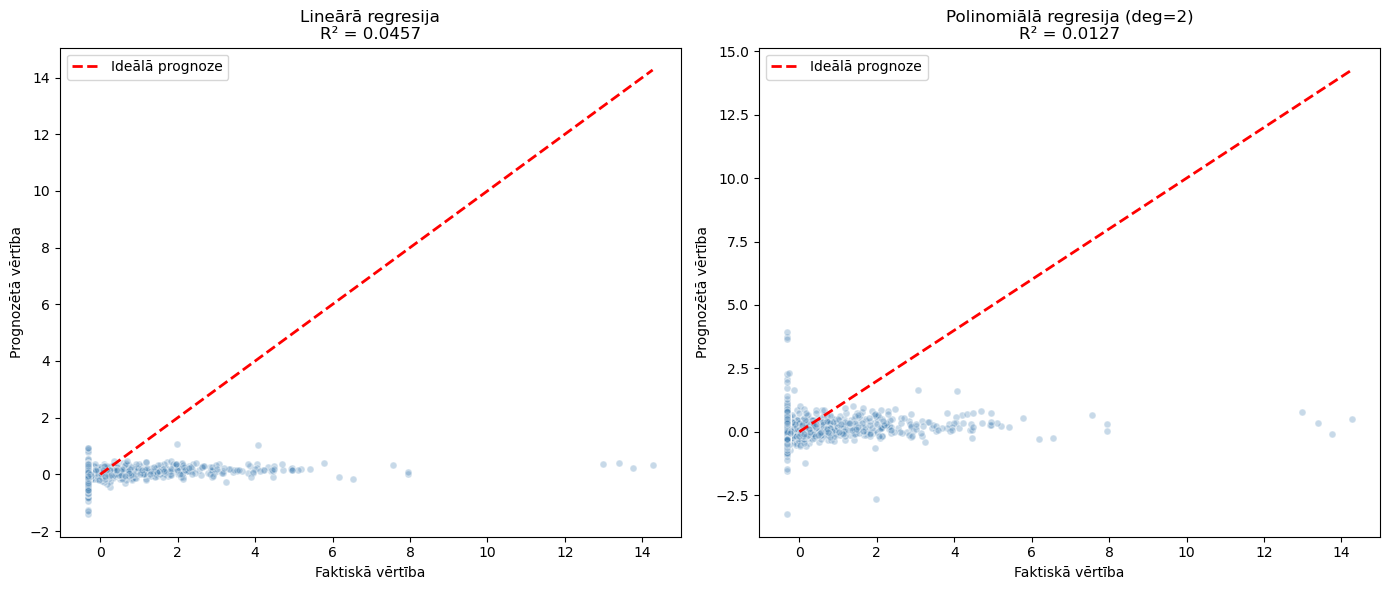

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modeļi = [
    ('Lineārā regresija', y_pred, r2),
    ('Polinomiālā regresija (deg=2)', y_pred_poly, r2_poly)
]

for ax, (title, preds, r2_val) in zip(axes, modeļi):
    ax.scatter(y_test, preds, alpha=0.3, color='steelblue',
               edgecolors='white', s=25)
    max_v = max(y_test.max(), preds.max())
    ax.plot([0, max_v], [0, max_v], 'r--', linewidth=2, label='Ideālā prognoze')
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.set_title(f'{title}\nR² = {r2_val:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

"""
## 4.5. Secinājumi: Lineārā vs. Polinomiālā regresija

**Kurš modelis labāk prognozē PageValues?**
Polinomiālā regresija (degree=2) teorētiski var uztvert nelineāras sakarības,
ko lineārais modelis nespēj. Tomēr PageValues gadījumā uzlabojums var būt minimāls,
jo galvenā problēma ir datu sadalījums — lielākā daļa vērtību ir 0, un tikai
mazs procents klientu ģenerē augstu PageValues. Šādos apstākļos abi modeļi cīnās.

**Vai polinomiālais modelis nopietni uzlaboja R²?**
Ja R² uzlabojums ir mazāks par 0.05, uzlabojums nav biznesa ziņā nozīmīgs.
Jāņem vērā, ka polinomiālais modelis ir daudz sarežģītāks (daudz vairāk features
pēc transformācijas), kas palielina overfitting risku un aprēķinu laiku.

**Vai ir overfitting pazīmes?**
Ja Train R² ir ievērojami augstāks par Test R² (starpība > 0.10) — tas liecina
par overfitting. Polinomiālajai regresijai šis risks ir augstāks.

**Biznesa ieteikums:**
E-komercijas vidē PageValues prognozēšanai lineārā regresija ir labāks sākumpunkts —
tā ir interpretējama, ātra un mazāk jutīga pret overfitting. Ja nepieciešama augstāka
precizitāte, vērts izmēģināt Random Forest regresoru, kas labāk uztver nelineāras
sakarības nekā polinomiālā regresija, vienlaikus saglabājot robustumu.
"""